# Ler base de dados

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
equipDB = pd.read_csv("EquipDB.csv", header=None, names=["ID_equipamento", "TempoAposFalha", "Cluster", "CustoDeFalha"])
ClusterDB= pd.read_csv("ClusterDB.csv", header=None, names=["ID_Cluster", "eta", "beta"])
MPDB=pd.read_csv("MPDB.csv", header=None, names=["ID_plano_risco", "Fator_risco(k)", "CustoDoPlano"])

# Unir informações do ClusterDB ao equipDB
equipDB = equipDB.merge(ClusterDB, left_on="Cluster", right_on="ID_Cluster")


# Formula de Weibull

$P_{ij}$ é a probabilidade de falha do equipmento $i$ sob o plano de manutenção $j$

In [20]:
def Fi(t, eta, beta):
    return 1-np.exp(-(t/eta)**beta)

def P(t0, eta, beta, k, delta_t):
    return (Fi((t0+k*delta_t), eta=eta, beta=beta)-Fi(t=t0, eta=eta, beta=beta))/(1-Fi(t=t0, eta=eta, beta=beta))

# Modelo Matematicos

## Modelo para $f2(*)$


## Conjuntos e Parâmetros
$I$: Conjunto de equipamentos ($|I| = 500$, $i \in I$)

$J = \{1,2,3\}$: Planos de manutenção disponíveis ($j \in J$)

$C = \{1,2,3,4\}$: Clusters de equipamentos ($c \in C$)

$t_0^i$: Idade atual do equipamento $i$ (em anos)

$\text{c}_i$: Cluster ao qual pertence o equipamento $i$

$\text{f}_i$: Custo associado à falha do equipamento $i$

$k_j$: Fator de risco do plano de manutenção $j$

$\text{m}_j$: Custo de aplicar o plano $j$ a um equipamento

$\eta_c$: Parâmetro de escala (Weibull) para o cluster $c$

$\beta_c$: Parâmetro de forma (Weibull) para o cluster $c$

$p_{i,j}$: probabilidade de falha do equipmento $i$ sob o plano de manutenção $j$

$\Delta t = 5$ anos: Horizonte de planejamento


### Varaivel de decisão
$$
x_{i} \in \{1,2,3\} \quad \forall i \in I $$
$$

\begin{align}
f_1(\mathbf{x}) &=\min \sum_{i \in I} \text{m}_{ x_i} \quad \text{(Custo total de manutenção)} \\
f_2(\mathbf{x}) &= \min \sum_{i \in I}  p_{i,x_i} \cdot \text{f}_i \quad \text{(Custo esperado de falha)}
\end{align}$$
onde: 

$$
\begin{align}
p_{i,j} = \frac{F_{c(i)}(t_0^i + k_j \Delta t) - F_{c(i)}(t_0^i)}{1 - F_{c(i)}(t_0^i)} \\
F_c(t) = 1 - \exp\left[-\left(\frac{t}{\eta_c}\right)^{\beta_c}\right]
\end{align}$$


$$

## Variavel de decisão

In [21]:
# Criar a matriz  de probabilidade Pij
Pij = np.zeros((len(equipDB), len(MPDB)))
delta_t = 5  # Definir um valor para Delta_t,

for i, equipamento in equipDB.iterrows():
    t0 = equipamento["TempoAposFalha"]
    eta = equipamento["eta"]
    beta = equipamento["beta"]
    
    for j, plano in MPDB.iterrows():
        k = plano["Fator_risco(k)"]
        Pij[i, j] = P(t0, eta, beta, k, delta_t)

# Converter a matriz para um DataFrame para melhor visualização
Pij_df = pd.DataFrame(Pij, index=equipDB["ID_equipamento"], columns=MPDB["ID_plano_risco"])


## Geração Solução Inicial (Cálculo do Índice Crítico)
Para cada equipamento $i$, calcule o índice de criticidade:

$$
\text{Índice}_i = \text{custo\_falha}_i \times p_{i,\text{nenhuma}} \times t_0^i
$$

onde:

$\text{custo\_falha}_i$: Custo associado à falha do equipamento $i$

$p_{i,\text{nenhuma}}$: Probabilidade de falha se nenhuma manutenção for aplicada (plano $j=1$)

$t_0^i$: Tempo de operação

## Alocação de Planos de Manutenção

Ordene os equipamentos em ordem $\textbf{decrescente}$ de $\text{Índice}_i$ e aloque os planos:


$\textbf{Top 20\%}$ equipamentos: Manutenção detalhada (plano $j=3$)


$\textbf{Próximos 30\%}$: Manutenção intermediária (plano $j=2$)

$\textbf{Restante 50\%}$: Nenhuma manutenção (plano $j=1$)

In [4]:
def gerar_Xij_inicial(equipDB, MPDB, Pij):
    """Gera uma solução inicial balanceada para Xij."""
    n_equip = len(equipDB)
    Xij = np.zeros((n_equip, len(MPDB)))
    
    # Critério de criticidade: custo_falha * probabilidade sem manutenção
    criticidade = equipDB["CustoDeFalha"].values * Pij[:, 0]*equipDB["TempoAposFalha"]
    equip_ordenados = np.argsort(-criticidade)  # Ordem decrescente
    
    # Distribuição 20% detalhada, 30% intermediária, 50% nenhuma
    for idx, i in enumerate(equip_ordenados):
        if idx < 0.2 * n_equip:
            Xij[i, 2] = 1  # Plano 3 (detalhada)
        elif idx < 0.5 * n_equip:
            Xij[i, 1] = 1  # Plano 2 (intermediária)
        else:
            Xij[i, 0] = 1  # Plano 1 (nenhuma)
    
    return Xij
Xij=gerar_Xij_inicial(equipDB=equipDB, MPDB=MPDB, Pij=Pij)

In [35]:
# Heurística construtiva baseada em criticidade
def gerar_solucao_inicial(equipDB, Pij):
    criticidade = equipDB["CustoDeFalha"].values * Pij[:, 0] * equipDB["TempoAposFalha"].values
    ordem = np.argsort(-criticidade)
    solucao = np.ones(len(equipDB), dtype=int)
    n = len(equipDB)
    for idx, i in enumerate(ordem):
        if idx < 0.2 * n:
            solucao[i] = 3
        elif idx < 0.5 * n:
            solucao[i] = 2
        else:
            solucao[i] = 1
    return solucao

gerar_solucao_inicial(equipDB, Pij)

array([1, 1, 3, 1, 1, 3, 1, 3, 1, 1, 1, 2, 1, 1, 3, 1, 3, 1, 2, 3, 3, 2,
       1, 2, 2, 2, 3, 1, 1, 1, 2, 2, 1, 2, 2, 3, 2, 2, 1, 1, 3, 1, 2, 2,
       1, 2, 1, 1, 1, 3, 1, 2, 2, 1, 1, 1, 2, 2, 1, 3, 2, 1, 1, 1, 2, 2,
       2, 3, 1, 3, 1, 2, 2, 1, 1, 1, 1, 2, 1, 1, 1, 3, 2, 1, 1, 1, 1, 3,
       1, 2, 2, 1, 1, 3, 1, 2, 1, 3, 2, 3, 2, 2, 1, 1, 3, 1, 1, 1, 1, 1,
       2, 2, 1, 1, 3, 1, 3, 1, 1, 1, 3, 1, 1, 1, 3, 1, 2, 1, 1, 1, 1, 1,
       1, 1, 1, 2, 3, 2, 1, 3, 2, 2, 3, 1, 3, 3, 2, 2, 3, 2, 1, 1, 2, 1,
       1, 2, 2, 2, 1, 2, 1, 1, 3, 2, 1, 3, 1, 1, 2, 1, 2, 2, 2, 3, 1, 1,
       2, 1, 2, 1, 1, 1, 3, 1, 1, 2, 3, 2, 1, 1, 1, 3, 1, 3, 3, 1, 1, 1,
       2, 3, 1, 2, 1, 3, 1, 1, 2, 1, 2, 3, 1, 1, 2, 1, 2, 1, 1, 3, 2, 1,
       2, 1, 3, 1, 2, 1, 1, 3, 3, 3, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 2,
       1, 1, 2, 1, 3, 1, 1, 2, 2, 3, 1, 2, 1, 2, 3, 1, 1, 1, 2, 3, 1, 1,
       2, 2, 1, 2, 3, 1, 2, 1, 2, 2, 2, 3, 1, 1, 2, 3, 1, 2, 1, 3, 2, 1,
       1, 2, 2, 1, 1, 1, 1, 3, 2, 2, 3, 1, 3, 1, 1,

### Calcula o fit do ploblema

In [39]:
mj=MPDB.CustoDoPlano.values
fi=equipDB.CustoDeFalha.values
def f1(X, MPDB):
    """
    Calcula o custo total de manutenção.

    Parâmetros:
    - x: matriz numpy (n x 3) representando as variáveis de decisão x_{i,j}
    - m: vetor numpy (3,) representando os custos de manutenção m_j para cada coluna

    Retorna:
    - Custo total de manutenção (float)
    """
    return sum(MPDB.iloc[p - 1]["CustoDoPlano"] for p in X)

def f2(X, equipDB, MPDB, Pij):
    """
    Calcula o custo esperado de falha.

    Parâmetros:
    - x: matriz numpy (n x 3) representando as variáveis de decisão x_{i,j}
    - p: matriz numpy (n x 3) representando as probabilidades de falha p_{i,j}
    - f: vetor numpy (n,) representando os custos de falha f_i

    Retorna:
    - Custo esperado de falha (float)
    """
    return sum(
        Pij[i, X[i] - 1] * equipDB.loc[i, "CustoDeFalha"]
        for i in range(len(X))
    )
# print("Custo total de manutenção:",f1(Xij))
# print("Custo esperado de falha:", f2(Xij))

## Gerar tres estruturas de vizinhaça


### Vizinhança 1 - Move

Move um elemento do plano 𝑗  para o plano l.

Objetivo → Explorar novas combinaçõe

### Vizinhaça 2 - one-opt
Escolhe 1 par de elementos de 2 planos diferentes e troca suas posições.

Objetivo → Perturbação a solução

### Vizinhaça 3 - Cycle Shift entre Planos
Rotaciona 3 elementos entre 3 planos diferentes, sendo que pelos menos 2 elementos são diferenres:

elemento do plano:

A → vai pro plano B

B → vai pro C

C → vai pro A

Objetivo → Movimentação circular, gera boa perturbação.

In [ ]:
import random

def move(X):
    nova = X.copy()
    i = np.random.randint(len(X))
    nova[i] = np.random.choice([x for x in [1, 2, 3] if x != X[i]])
    return nova

# Vizinhança 2 - 1-opt entre planos
def one_opt(X):
    nova = X.copy()
    i, j = np.random.choice(len(X), 2, replace=False)
    for idx in [i, j]:
        nova[idx] = np.random.choice([x for x in [1, 2, 3] if x != X[idx]])
    return nova

def shift(X):
    nova = X.copy()
    if len(X) < 5:
        return move(X)
    i = np.random.randint(0, len(X) - 5)
    for j in range(i, i + 5):
        nova[j] = np.random.choice([x for x in [1, 2, 3] if x != X[j]])
    return nova

vizinhas = [move, one_opt, shift]

In [32]:
# Busca local
def busca_local(solucao, obj_func, *args):
    melhor = solucao.copy()
    melhor_valor = obj_func(melhor, *args)
    for viz in vizinhas:
        candidato = viz(melhor)
        valor = obj_func(candidato, *args)
        if valor < melhor_valor:
            return candidato
    return melhor

--- f1 (Custo de Manutenção) ---
Min: 155.0
Max: 190.0
Std: 11.408768557561329

--- f2 (Custo Esperado de Falha) ---
Min: 1141.7892980622905
Max: 1159.528900040747
Std: 6.034685129628684


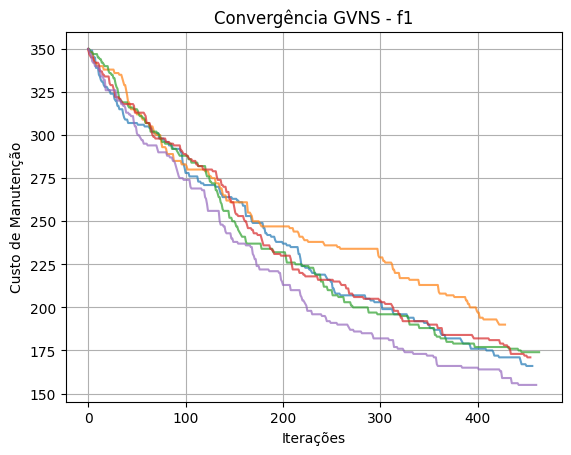

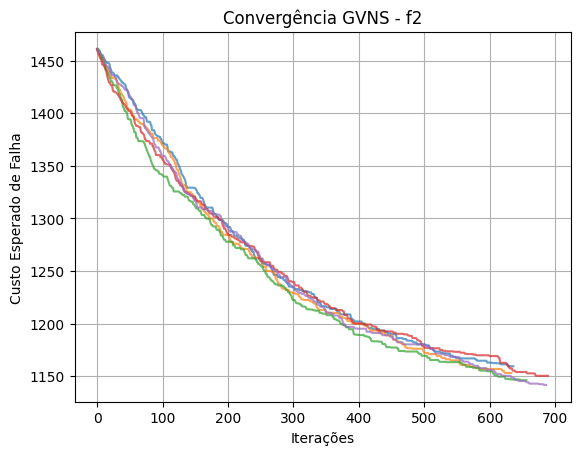

In [54]:
# GVNS

def GVNS(obj_func, equipDB, MPDB, Pij=None, max_iter=100, return_curve=False):
    if obj_func == f2:
        assert Pij is not None, "Pij é obrigatória para a função f2."
    s = gerar_solucao_inicial(equipDB, Pij)
    melhor = s.copy()
    historico = []
    valor_inicial = obj_func(melhor, MPDB) if obj_func == f1 else obj_func(melhor, equipDB, MPDB, Pij)
    historico.append(valor_inicial)
    for _ in range(max_iter):
        k = 0
        while k < len(vizinhas):
            s_ = vizinhas[k](melhor)
            s__ = busca_local(s_, obj_func, MPDB) if obj_func == f1 else busca_local(s_, obj_func, equipDB, MPDB, Pij)
            novo_valor = obj_func(s__, MPDB) if obj_func == f1 else obj_func(s__, equipDB, MPDB, Pij)
            if novo_valor < historico[-1]:
                melhor = s__.copy()
                historico.append(novo_valor)
                k = 0
            else:
                k += 1
                historico.append(historico[-1])
    return (melhor, historico) if return_curve else melhor

# Execução principal com 5 repetições
if __name__ == "__main__":
    resultados_f1 = [GVNS(f1, equipDB, MPDB, Pij, return_curve=True) for _ in range(5)]
    resultados_f2 = [GVNS(f2, equipDB, MPDB, Pij, return_curve=True) for _ in range(5)]

    custos_f1 = [f1(sol, MPDB) for sol, _ in resultados_f1]
    custos_f2 = [f2(sol, equipDB, MPDB, Pij) for sol, _ in resultados_f2]

    print("--- f1 (Custo de Manutenção) ---")
    print("Min:", np.min(custos_f1))
    print("Max:", np.max(custos_f1))
    print("Std:", np.std(custos_f1))

    print("\n--- f2 (Custo Esperado de Falha) ---")
    print("Min:", np.min(custos_f2))
    print("Max:", np.max(custos_f2))
    print("Std:", np.std(custos_f2))

    plt.figure()
    for _, hist in resultados_f1:
        plt.plot(hist, alpha=0.7)
    plt.title("Convergência GVNS - f1")
    plt.xlabel("Iterações")
    plt.ylabel("Custo de Manutenção")
    plt.grid(True)
    plt.show()

    plt.figure()
    for _, hist in resultados_f2:
        plt.plot(hist, alpha=0.7)
    plt.title("Convergência GVNS - f2")
    plt.xlabel("Iterações")
    plt.ylabel("Custo Esperado de Falha")
    plt.grid(True)
    plt.show()